# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Условие задачи в стандартной форме**

Пусть $x^{(0)} = (1, 2, 3)$ и $f(x) = ||x - x^{(0)}||_2^2 = (x_1-1)^2 + (x_2-2)^2 + (x_3-3)^2$ при $x \in \mathbb{R}^3$, тогда условие в стандартном виде:

$$\min\limits_{x \in \mathbb{R}^3} f(x) \quad\text{при}\quad g(x) = \begin{pmatrix} g_1(x) \\ g_2(x) \end{pmatrix} = \begin{pmatrix} x_1 + x_2 + x_3 - 1 \\ x_1 - x_3 \end{pmatrix} = 0$$

Задача является QP - квадратичного программирования с линейным ограничением. Функция f(x) является выпуклой:

$\nabla^2 f(x) = \begin{pmatrix} 2 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 2 \end{pmatrix}$ - определители всех главных миноров больше 0

**Решение задачи**

Найдем прямую, которая является пересечением двух плоскостей: $g_2(x) = 0 \rightarrow x_1 = x_3$, подставим в $g_1(x) = 2x_1 + x_2 - 1 = 0$. Таким образом, имеем систему:

$\begin{cases} x_2 = 1 - 2x_1 \\ x_3 = x_1 \end{cases}$

Пусть $x_1 = t$, тогда параметрический вид прямой:

$\begin{cases} x_1 = t \\ x_2 = 1 - 2t \\ x_3 = t \end{cases}$

Подставим значения из параметрического вида в ф-ю минимизации $f(t) = (t-1)^2+((1-2t)-2)^2+(t-3)^2 \rightarrow min$

$f'(t) = 2(t-1) - 4(-2t-1) + 2(t-3) = 0 \rightarrow 12t = 4 \rightarrow t=\dfrac{1}{3}$

Поскольку $f(t)$ является выпуклым ответ является глобальным минимумом.

Ответ: $x = (\dfrac{1}{3}, \dfrac{1}{3}, \dfrac{1}{3})$

**(б)**

**Условие задачи в стандартной форме**

По условию $c = (c_1, \dots, c_n)^T \in \mathbb{R}^n$, где $c_j$ - цена продукта $j$, $b = (b_1, \dots, b_m)^T \in \mathbb{R}^m$, где $b_j$ - минимальное количество вещества $j$, $A \in \mathbb{R}^{m\times n}$, где $A_{ij}$ - содерэание питального вещества $i$ в единице продукта $j$

Пусть $x=(x_1, \dots, x_n)^T \in \mathbb{R}^n$, где $x_j$ - количество продукта $j$, которое нужно купить. Тогда условие в стандартной форме имеет вид:

$$\min_\limits{x \in \mathbb{R}^n} f(x) = \min_\limits{x \in \mathbb{R}^n} c^T x \qquad h(x) = \begin{pmatrix} Ax - b \\ x \end{pmatrix} \ge 0$$

Задача является LP - линейного программирования, с линейными ограничениями. Задача выпуклая, так как линейная функция является выпуклой.


**(в)**

Пусть $(a, b) \in \mathbb{R}^2$, где a - длина, b - ширина вписанного прямоугольника. Введем систему координат. Пусть окружность находится в центре. Тогда координаты прямоугольника $(\pm\dfrac{a}{2}, \pm\dfrac{b}{2})$. Тогда уравнение окружности $(\dfrac{a}{2})^2+(\dfrac{b}{2})^2=1 \rightarrow a^2+b^2-4=0 $. Так как задача требуется максимизации, будем минизировать отрицание значения площади.

**Условие задачи в стандартном виде**

$$\min_\limits{a, b \in \mathbb{R}}-ab \quad\text{при}\quad g(a, b) = a^2 + b^2 - 4 = 0,\ h(a, b) = \begin{pmatrix} a \\ b \end{pmatrix} \ge 0$$

Задача QCQP — квадратично ограниченная квадратичная задача: целевая функция квадратичная, ограничение-равенство тоже квадратичное. Задача невыпуклая:

$\nabla^2f=\begin{pmatrix} 0 & -1 \\ -1 & 0 \end{pmatrix}$

**Решение**

Выведем сторону b в терминах стороны a, используя, что радиус равен 1. Проведем диагональ. Угол, который опирается на диалональ является прямым, что значит диагональ - это диаметр, то есть равен 2. Тогда:
$a^2+b^2=4 \rightarrow b = \sqrt{4-a^2}$

$\min f(a) = -a\sqrt{4-a^2}$

$f'(a) = \sqrt{4-a^2} + \dfrac{a \cdot (-2a)}{2\sqrt{4 -a^2}}=\dfrac{2(4-a^2) - 2a^2}{2\sqrt{4-a^2}}=0$


$8 - 4a^2 = 0 \rightarrow a = \sqrt{2}$

Ответ: Вписанный прямоугольник наибольшой площади - это вписанный квадрат со сторонами $\sqrt{2}$ 

**(г)**

**Условие задачи в стандартном виде**

Пусть $x=(x_1, x_2, x_3)^T \in \mathbb{R}^3$ и пусть $f(x) = \displaystyle\sum_{i=1}^N (y_i - \varphi(t_i; x))^2 = \displaystyle\sum_{i=1}^N (y_i - x_1sin(x_2t_i+x_3))^2$ - сумма квадратов невязок. Требуется:

$\min_\limits{x \in \mathbb{R}^3} f(x)$

Задача является NLP - нелинейного программирования, без ограничений. Задача является невыпуклой:

$\nabla^2 f(x)=2\displaystyle\sum_{i=1}^N
\begin{pmatrix}
\sin^2(x_2t_i+x_3) & t_i\cos(x_2t_i+x_3)\bigl(2x_1\sin(x_2t_i+x_3)-y_i\bigr) & \cos(x_2t_i+x_3)\bigl(2x_1\sin(x_2t_i+x_3)-y_i\bigr)\\[1mm]
t_i\cos(x_2t_i+x_3)\bigl(2x_1\sin(x_2t_i+x_3)-y_i\bigr) & x_1^2t_i^2\bigl(\cos^2(x_2t_i+x_3)-\sin^2(x_2t_i+x_3)\bigr)+x_1t_i^2y_i\sin(x_2t_i+x_3) & x_1^2t_i\bigl(\cos^2(x_2t_i+x_3)-\sin^2(x_2t_i+x_3)\bigr)+x_1t_iy_i\sin(x_2t_i+x_3)\\[1mm]
\cos(x_2t_i+x_3)\bigl(2x_1\sin(x_2t_i+x_3)-y_i\bigr) & x_1^2t_i\bigl(\cos^2(x_2t_i+x_3)-\sin^2(x_2t_i+x_3)\bigr)+x_1t_iy_i\sin(x_2t_i+x_3) & x_1^2\bigl(\cos^2(x_2t_i+x_3)-\sin^2(x_2t_i+x_3)\bigr)+x_1y_i\sin(x_2t_i+x_3)
\end{pmatrix}$

Для $\forall x_1,\ x_2 = 0,\ x_3 = 0 \ \ sin^2(x_2t_i+x_3) = 0$, то есть не выполняется критерий Сильвестра

**(д, бонус)**

Пусть $x\in\mathbb{R}^n$ и введем дополнительную переменную $t\in\mathbb{R}$, которая будет ограничивать максимальную абсолютную невязку. Тогда исходную задачу

$$
\min_{x\in\mathbb{R}^n}\max_i |a_i^\top x-b_i|
$$

можно переписать в виде:

$$
\min_{x\in\mathbb{R}^n,\ t\in\mathbb{R}} t
\quad\text{при}\quad
|a_i^\top x-b_i|\leq t,\quad i=1,\dots,m.
$$

Раскроем модуль, получим два линейных неравенства для каждого $i$:

$$
a_i^\top x-b_i\leq t,
$$

$$
-(a_i^\top x-b_i)\leq t.
$$

Перенесем всё в левую часть и запишем в требуемом виде $h(x,t)\geq0$:

$$
t-a_i^\top x+b_i\geq0,
$$

$$
t+a_i^\top x-b_i\geq0,
\qquad i=1,\dots,m.
$$

Введем новый вектор переменных

$$
\tilde{x}=
\begin{pmatrix}
x\\
t
\end{pmatrix}
\in\mathbb{R}^{n+1}.
$$

Тогда задача в стандартной форме имеет вид:

$$
\min_{\tilde{x}\in\mathbb{R}^{n+1}} f(\tilde{x})=t
$$

при

$$
g(\tilde{x})=\varnothing,
$$

$$
h(\tilde{x})=
\begin{pmatrix}
t-a_1^\top x+b_1\\
\vdots\\
t-a_m^\top x+b_m\\
t+a_1^\top x-b_1\\
\vdots\\
t+a_m^\top x-b_m
\end{pmatrix}
\geq0.
$$

Все функции в полученной задаче линейные, поэтому задача является **LP — задачей линейного программирования**, без ограничений-равенств, но с линейными неравенствами. Задача выпуклая, так как целевая функция и ограничения линейные.


## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

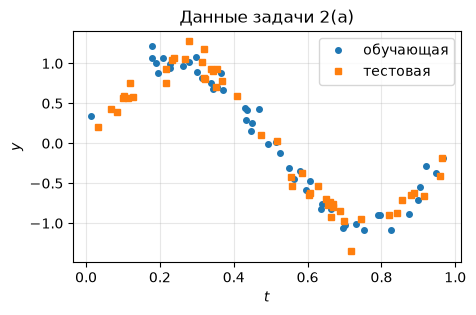

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)"); plt.grid(alpha=0.3)
plt.show()

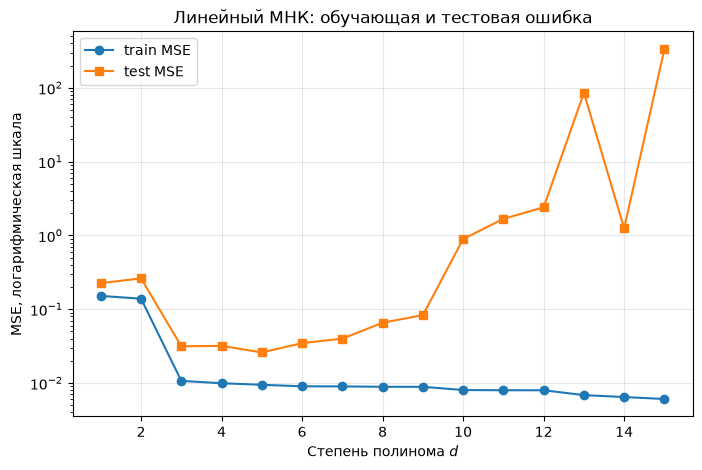

In [57]:
degrees = np.arange(1, 16)
train_mse = []
test_mse = []

for d in degrees:
    A_train = np.vander(t_train, d + 1, increasing=True)
    A_test = np.vander(t_test, d + 1, increasing=True)
    
    x, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    y_predict_train = A_train @ x
    y_predict_test = A_test @ x

    train_mse.append(np.mean((y_train - y_predict_train)**2))
    test_mse.append(np.mean((y_test - y_predict_test)**2))

plt.figure(figsize=(8, 5))
plt.semilogy(degrees, train_mse, 'o-', label='train MSE')
plt.semilogy(degrees, test_mse, 's-', label='test MSE')
plt.xlabel('Степень полинома $d$')
plt.ylabel('MSE, логарифмическая шкала')
plt.title('Линейный МНК: обучающая и тестовая ошибка')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Общучающая ошибка монотонно убывает с ростом d, поскольку при увеличении степени полинома добавляется новый параметр с помощью которого можно подогнать данные. При d равной обьему выборки можно интерполировать каждую точку и получить нулевую ошибку. Тестовая ошибка сначала уменьшается, поскольку при малых d модель слишком простая и не описывает функцию синуса, поэтому ошибка велика. После некоторой степени начинается сильное переобучение модели на треноровочной выборке: полином подгоняет случайный шум.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [50]:
c = np.array([2.0, 3.0, 1.5, 4.0])                   # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                      # минимальные требования

In [56]:
def report(c: np.ndarray, A: np.ndarray, b: np.ndarray, title=None, epsilon=1e-9):
    result = linprog(c, A_ub=-A, b_ub=-b, bounds=(0, None))
    print(f'--{title}--')
    print(f'Статус: {result.message}')
    print(f'Оптимальное значение x: {result.x}')
    print(f'Оптимальная стоимость: {result.fun}')

    Ax = A @ result.x
    print("Активные ограничения Ax >= b:")
    for i in range(len(b)):
        err = abs(Ax[i] - b[i])
        if err < epsilon:
            print(f'  активно: вещество {i+1} (Ax={Ax[i]:.6f}, b={b[i]})')

    print("Активные ограничения x >= 0:")
    for j in range(len(result.x)):
        if abs(result.x[j]) < epsilon:
            print(f'  активно: x{j+1} = 0')

b_new = b.copy()
b_new[0] = b_new[0] + 1

report(c, A, b, 'Исходная задача')
report(c, A, b_new, 'b1 = b1 + 1')

--Исходная задача--
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Оптимальное значение x: [ 2.  4. -0.  0.]
Оптимальная стоимость: 16.0
Активные ограничения Ax >= b:
  активно: вещество 1 (Ax=10.000000, b=10.0)
  активно: вещество 2 (Ax=8.000000, b=8.0)
  активно: вещество 3 (Ax=12.000000, b=12.0)
Активные ограничения x >= 0:
  активно: x3 = 0
  активно: x4 = 0
--b1 = b1 + 1--
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Оптимальное значение x: [1.88888889 3.55555556 0.         0.66666667]
Оптимальная стоимость: 17.11111111111111
Активные ограничения Ax >= b:
  активно: вещество 1 (Ax=11.000000, b=11.0)
  активно: вещество 2 (Ax=8.000000, b=8.0)
  активно: вещество 3 (Ax=12.000000, b=12.0)
Активные ограничения x >= 0:
  активно: x3 = 0


Решение изменилось: часть продуктов стала использоваться меньше, один ранее неиспользуемый продукт вошёл в оптимальный набор, один так и остался неиспользуемым. Стоимость при этом выросла. Набор активных ограничений тоже изменился: ограничение неотрицательности для вошедшего в решение продукта перестало быть активным, а все ограничения по веществам и неотрицательность оставшегося нулевого продукта остались активными.